# Additional Flight Dataset EDA

Additional analyses to augment the existing project EDA.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/flights.csv')
df['date'] = pd.to_datetime(df['date'])
df.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019-09-26
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019-09-30
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019-10-03
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,2019-10-04
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019-10-10


## Basic Dataset Summary

In [3]:
print('Shape:', df.shape)
print('\nMissing Values:')
print(df.isna().sum())
print('\nDate Range:')
print(df['date'].min(), 'to', df['date'].max())

Shape: (271888, 10)

Missing Values:
travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64

Date Range:
2019-09-26 00:00:00 to 2023-07-24 00:00:00


## Route Analysis

In [4]:
df['route'] = df['from'] + ' -> ' + df['to']
route_stats = df.groupby('route')['price'].agg(['count','mean','median']).sort_values('mean', ascending=False)
route_stats.head(20)

,count,mean,median
route,,,
Sao Paulo (SP) -> Florianopolis (SC),6717,1380.881239,1370.17
Campo Grande (MS) -> Rio de Janeiro (RJ),2415,1371.030729,1363.27
Brasilia (DF) -> Salvador (BH),2009,1366.796635,1346.60
Aracaju (SE) -> Salvador (BH),2918,1364.968773,1289.05
Rio de Janeiro (RJ) -> Recife (PE),1897,1361.202604,1333.52
Natal (RN) -> Salvador (BH),926,1357.972387,1315.97
Florianopolis (SC) -> Salvador (BH),5800,1350.408472,1367.88
Salvador (BH) -> Florianopolis (SC),5800,1346.089441,1336.68
Recife (PE) -> Rio de Janeiro (RJ),1897,1341.604175,1351.89


## Flight Type Pricing

In [5]:
df.groupby('flightType')['price'].agg(['count','mean','median']).sort_values('mean')

,count,mean,median
flightType,,,
economic,77466,658.443093,674.52
premium,78004,920.392375,932.84
firstClass,116418,1181.067727,1190.94


## Agency Analysis

In [6]:
df.groupby('agency')['price'].agg(['count','mean','median']).sort_values('mean', ascending=False)

,count,mean,median
agency,,,
FlyingDrops,38758,1186.160378,1269.73
Rainbow,116752,919.780760,870.91
CloudFy,116378,918.896483,883.63


## Correlation Analysis

             price     time  distance
price     1.000000  0.64180  0.641915
time      0.641800  1.00000  0.999990
distance  0.641915  0.99999  1.000000


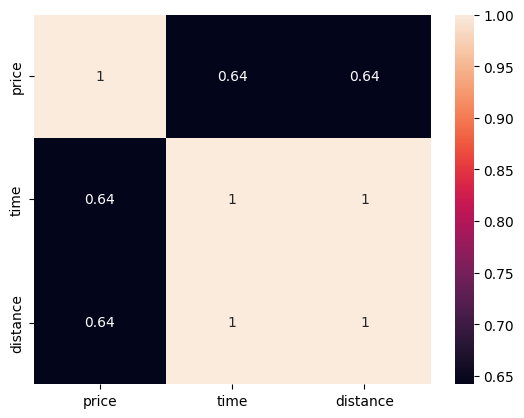

In [7]:
num_cols = ['price','time','distance']
corr = df[num_cols].corr()
print(corr)
sns.heatmap(corr, annot=True)
plt.show()

## Distance vs Time Redundancy

In [8]:
print('Distance-Time Correlation:', df['distance'].corr(df['time']))

Distance-Time Correlation: 0.9999904128766205


## Monthly Seasonality

month
1     951.030196
2     958.375553
3     959.520161
4     955.448870
5     962.668626
6     962.735349
7     961.322445
8     958.246613
9     953.662784
10    954.556268
11    957.628031
12    956.388657
Name: price, dtype: float64


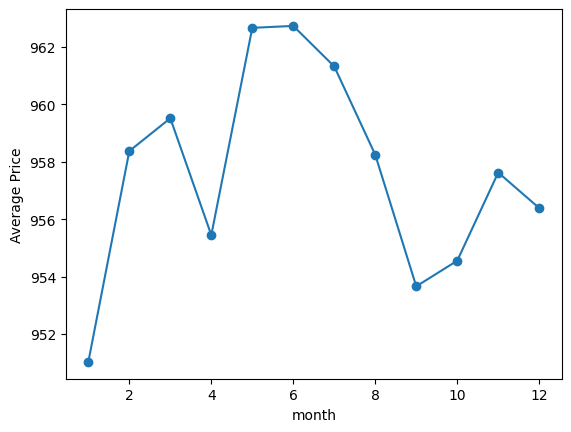

In [9]:
df['month'] = df['date'].dt.month
monthly = df.groupby('month')['price'].mean()
print(monthly)
monthly.plot(marker='o')
plt.ylabel('Average Price')
plt.show()

## Feature Engineering Ideas

In [10]:
df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)
df['day_of_month'] = df['date'].dt.day
df['days_from_start'] = (df['date'] - df['date'].min()).dt.days

print(df[['is_weekend','day_of_month','days_from_start']].head())

   is_weekend  day_of_month  days_from_start
0           0            26                0
1           0            30                4
2           0             3                7
3           0             4                8
4           0            10               14


In [11]:
df.columns

Index(['travelCode', 'userCode', 'from', 'to', 'flightType', 'price', 'time',
       'distance', 'agency', 'date', 'route', 'month', 'is_weekend',
       'day_of_month', 'days_from_start'],
      dtype='object')

Inspecting the Dates

In [12]:
full_range = pd.date_range(
    start=df['date'].min(),
    end=df['date'].max(),
    freq='D'
)

missing_dates = full_range.difference(df['date'].sort_values().unique())

print("Missing dates:", len(missing_dates))

print(missing_dates)

Missing dates: 399
DatetimeIndex(['2019-10-01', '2019-10-02', '2019-10-08', '2019-10-09',
               '2019-10-15', '2019-10-16', '2019-10-22', '2019-10-23',
               '2019-10-29', '2019-10-30',
               ...
               '2023-06-21', '2023-06-27', '2023-06-28', '2023-07-04',
               '2023-07-05', '2023-07-11', '2023-07-12', '2023-07-18',
               '2023-07-19', '2023-07-22'],
              dtype='datetime64[ns]', length=399, freq=None)


Date Counts

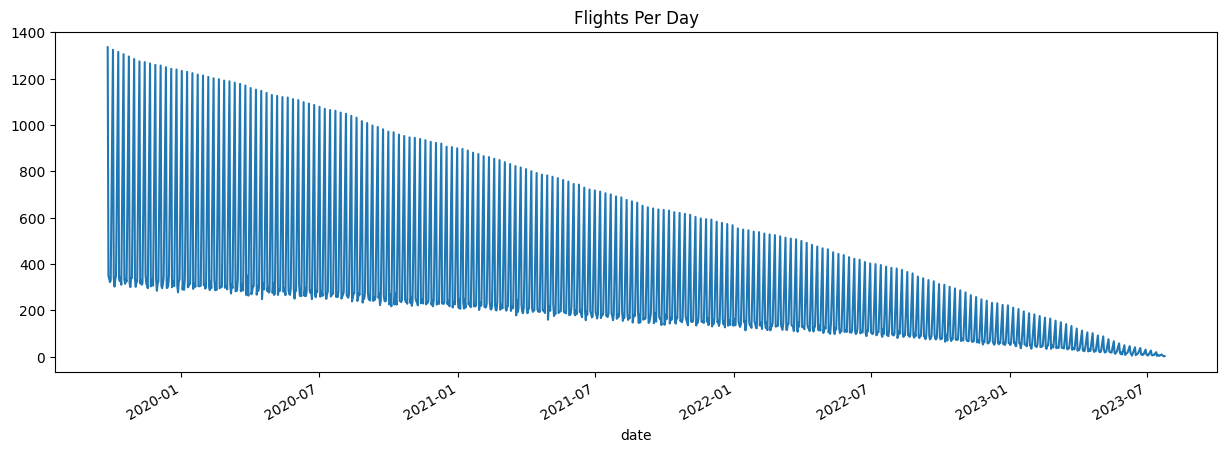

In [13]:
daily_counts = df.groupby('date').size()

plt.figure(figsize=(15,5))
daily_counts.plot()
plt.title("Flights Per Day")
plt.show()

Daily Average Price Trend

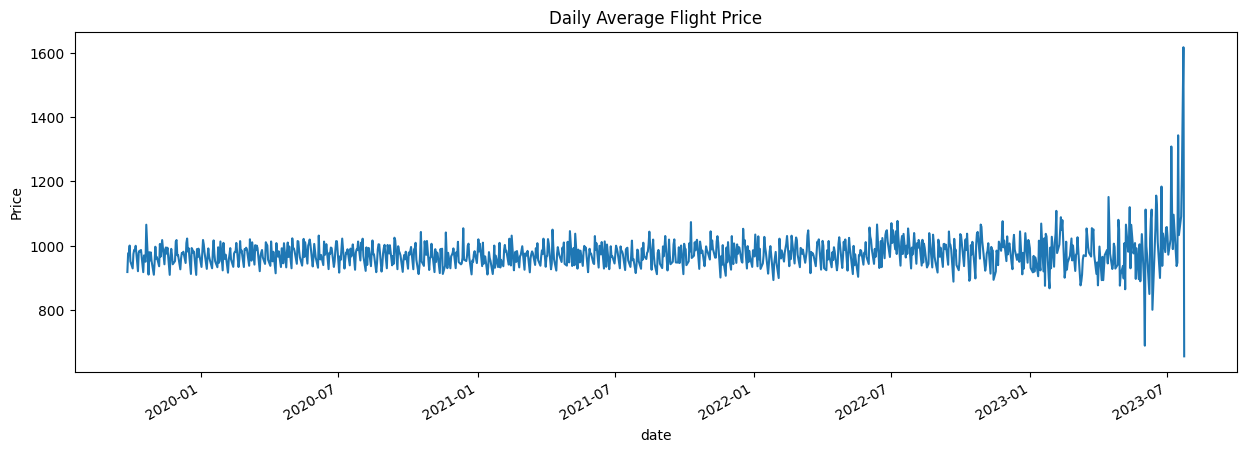

In [14]:
daily_avg = (
    df.groupby('date')['price']
      .mean()
)

plt.figure(figsize=(15,5))
daily_avg.plot()
plt.title("Daily Average Flight Price")
plt.ylabel("Price")
plt.show()

C:\Users\Ankur Bhatt\AppData\Local\Temp\ipykernel_2596\1564639942.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M', on='date')['price']


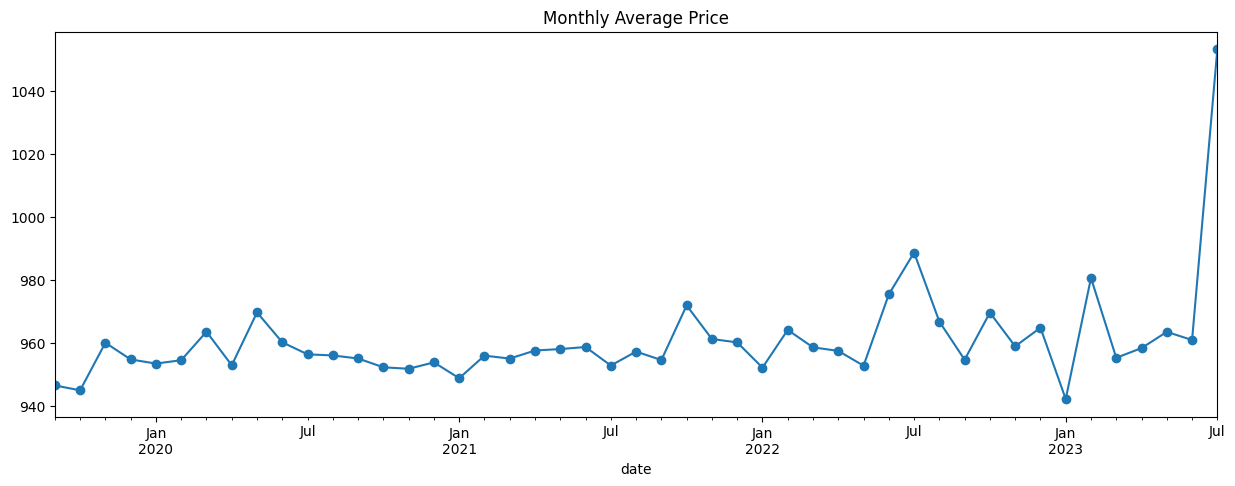

In [15]:
# Monthly Trend 
monthly_avg = (
    df.resample('M', on='date')['price']
      .mean()
)

plt.figure(figsize=(15,5))
monthly_avg.plot(marker='o')
plt.title("Monthly Average Price")
plt.show()

C:\Users\Ankur Bhatt\AppData\Local\Temp\ipykernel_2596\1307060718.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df.resample('Y', on='date')['price']


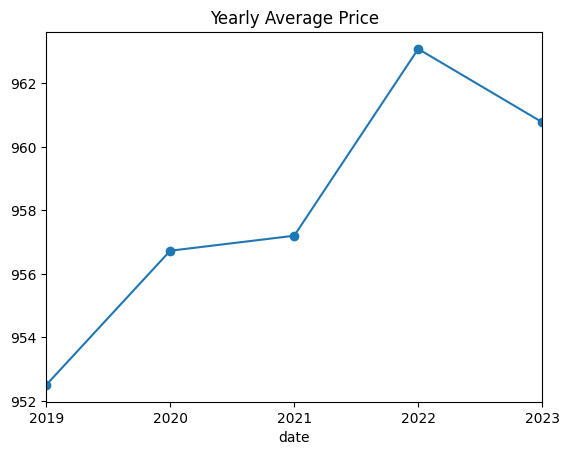

In [16]:
# Yearly Trend 
yearly_avg = (
    df.resample('Y', on='date')['price']
      .mean()
)

yearly_avg.plot(marker='o')
plt.title("Yearly Average Price")
plt.show()

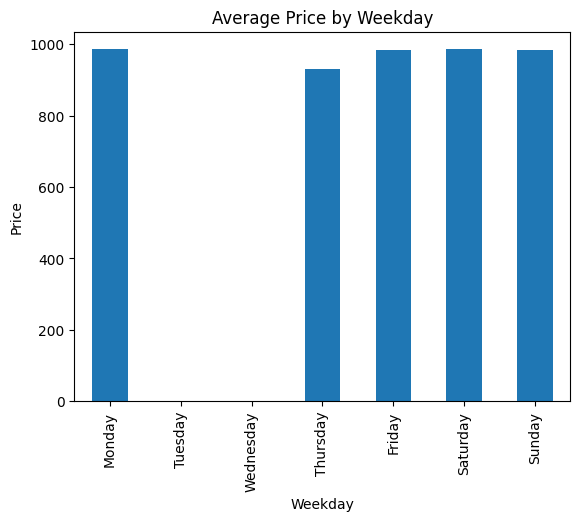

In [17]:
# WeekDay Effect 
df['weekday'] = df['date'].dt.day_name()

weekday_price = (
    df.groupby('weekday')['price']
      .mean()
      .reindex([
          'Monday',
          'Tuesday',
          'Wednesday',
          'Thursday',
          'Friday',
          'Saturday',
          'Sunday'
      ])
)

weekday_price.plot(kind='bar')
plt.title("Average Price by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Price")
plt.show()

In [18]:
# Weekend Effect

df['is_weekend'] = (
    df['date'].dt.dayofweek >= 5
).astype(int)

print(
    df.groupby('is_weekend')['price'].mean()
)

is_weekend
0    948.252613
1    984.750871
Name: price, dtype: float64


Monthly Seasonlity

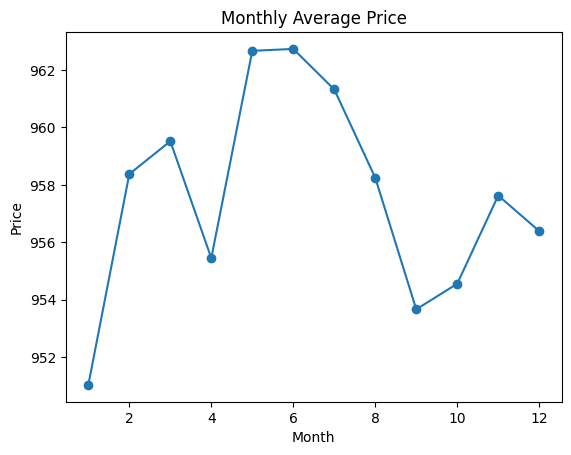

In [19]:
df['month'] = df['date'].dt.month

monthly_pattern = (
    df.groupby('month')['price']
      .mean()
)

monthly_pattern.plot(marker='o')
plt.title("Monthly Average Price")
plt.xlabel("Month")
plt.ylabel("Price")
plt.show()

In [ ]:
# Day of Week Distribution -> Thrusday have the highest number of flights. No Flight records associated with Tuesday and Wednesday.
df['date'].dt.day_name().value_counts().sort_index()

date
Friday       33880
Monday       34108
Saturday     33868
Sunday       34088
Thursday    135944
Name: count, dtype: int64

In [21]:
# Data Sampling Bias 
yearly_counts = df.groupby(
    df['date'].dt.year
).size()

print(yearly_counts)

date
2019     35826
2020    112571
2021     75363
2022     41761
2023      6367
dtype: int64


Trend - Seasonality - Residual

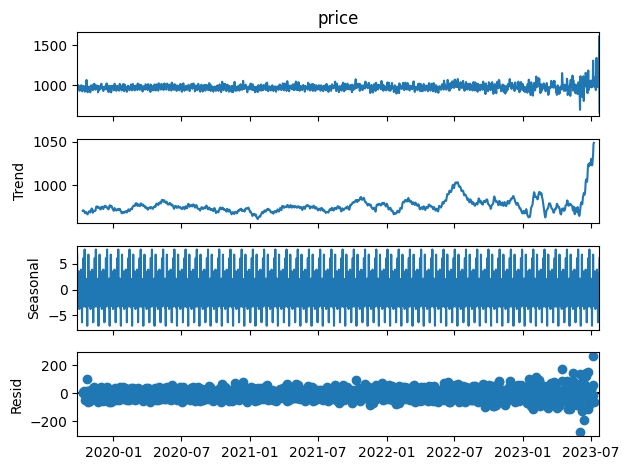

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

daily_avg = (
    df.groupby('date')['price']
      .mean()
      .asfreq('D')
)

daily_avg = daily_avg.fillna(
    daily_avg.mean()
)

result = seasonal_decompose(
    daily_avg,
    model='additive',
    period=30
)

result.plot()
plt.show()